Project: AI-Powered Task Management System — Hospital Length of Stay Prediction Dataset: AV Healthcare Analytics II (Kaggle) Prepared by: Sanjay Srinivas B

Goals of this notebook

Understand the structure and contents of the dataset (EDA)
Handle missing values, duplicate records, and inconsistent data
Visualize distributions and relationships (histograms, bar charts, correlation heatmap, count plots)
Save a cleaned dataset ready for NLP/feature engineering in Week 2

Top 10 most frequent patients:
            n_visits   avg_stay  avg_deposit      severity_mix
patientid                                                    
66714            50  63.710000  4418.800000   {'Extreme': 50}
91292            43  87.720930  5080.651163  {'Moderate': 43}
38525            39  54.076923  4427.512821  {'Moderate': 39}
101359           36  91.208333  4501.027778  {'Moderate': 36}
33491            34  50.161765  4751.323529  {'Moderate': 34}
32886            32  61.000000  4547.437500   {'Extreme': 32}
6645             31  65.016129  4644.419355   {'Extreme': 31}
31203            30  75.650000  4742.733333   {'Extreme': 30}
99644            30  39.766667  4770.766667   {'Extreme': 30}
126596           29  75.310345  4188.689655   {'Extreme': 29}

% of records from repeat patients (2+ visits): 93.6%


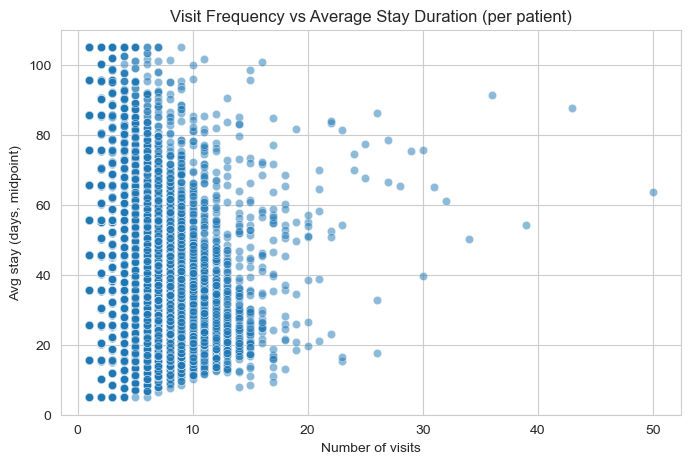

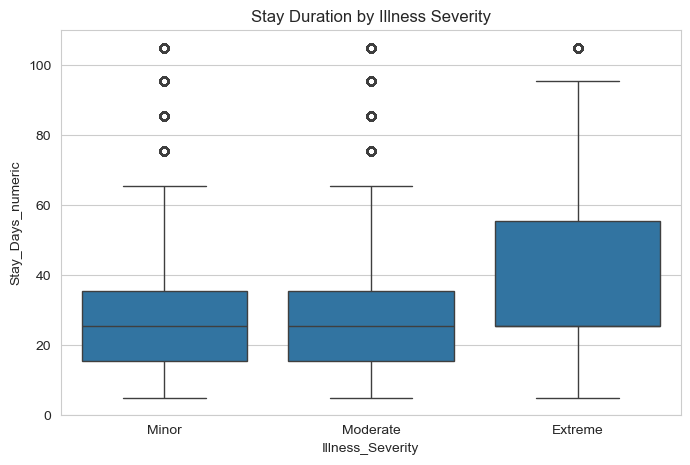

                     count       mean        std  min   25%   50%   75%    max
Illness_Severity                                                              
Extreme            56723.0  36.767308  23.743004  5.0  25.5  25.5  55.5  105.0
Minor              85872.0  28.625792  19.173562  5.0  15.5  25.5  35.5  105.0
Moderate          175843.0  32.903041  21.524752  5.0  15.5  25.5  35.5  105.0


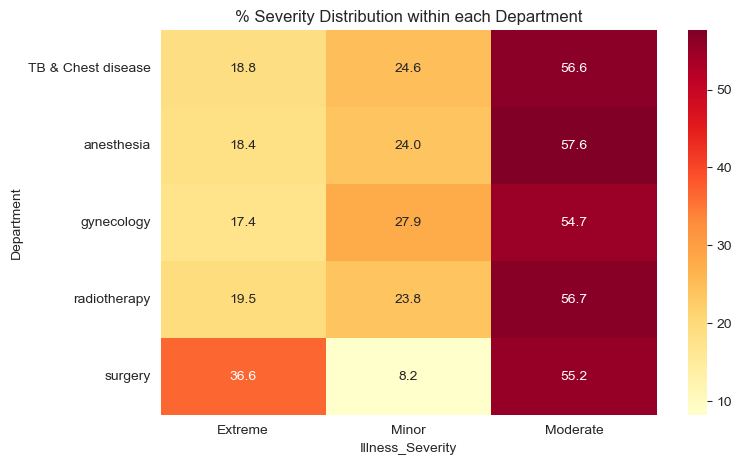


Chi2 = 1269.49, p-value = 0.0000
Significant association


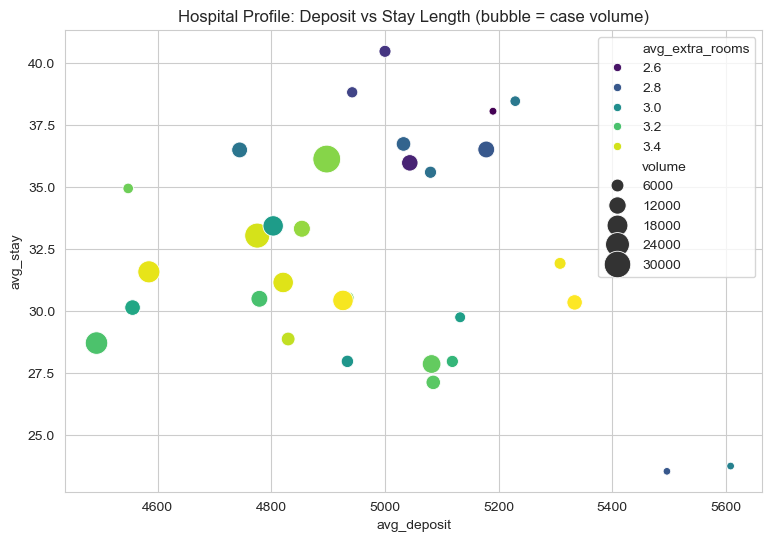

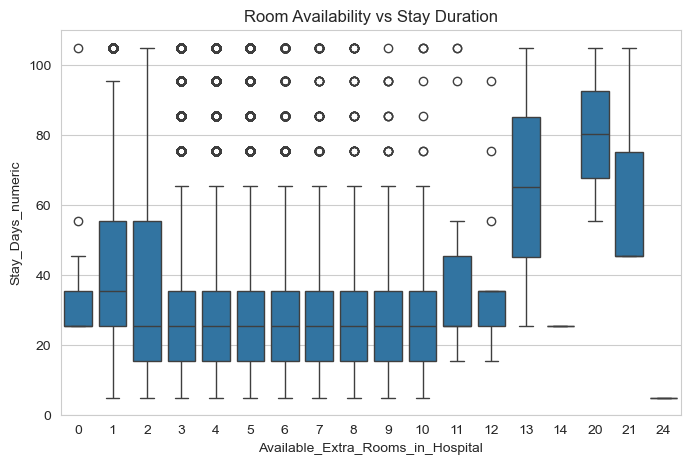


Outlier count by department:
 Department
TB & Chest disease     301
anesthesia             857
gynecology            9830
radiotherapy          1003
surgery                 41
Name: deposit_outlier, dtype: int64

Long-stay cases: 6683 (2.1% of data)
Illness_Severity  Department  Patient_Visitors  Type of Admission
Moderate          gynecology  6                 Trauma               281
                                                Emergency            238
                              8                 Trauma               208
                                                Emergency            201
                              4                 Trauma               181
Extreme           gynecology  6                 Trauma               161
                                                Emergency            161
Moderate          gynecology  4                 Emergency            143
                              10                Trauma               123
Extreme           gynecolo

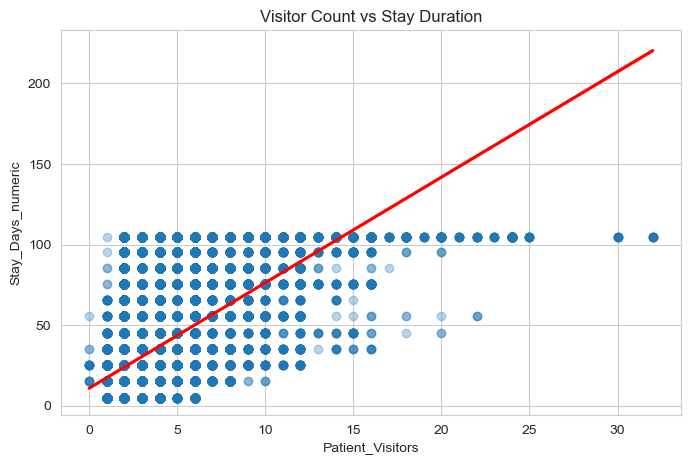


Correlation matrix (numeric-encoded features):
Stay_Days_numeric                    1.000000
Patient_Visitors                     0.536680
Severity_ordinal                     0.126170
Age_numeric                          0.094145
Bed_Grade                            0.025652
Admission_Deposit                   -0.051525
Available_Extra_Rooms_in_Hospital   -0.120969
Name: Stay_Days_numeric, dtype: float64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv(r'C:\Users\Admin\OneDrive\New folder\AI-Powered-Task-Management-System\host_train.csv (2).xls')

# ============================================================
# 1. Convert binned Age & Stay_Days to numeric (ordinal midpoints)
#    This unlocks correlation, regression-style analysis, etc.
# ============================================================
def bin_to_midpoint(val):
    if pd.isna(val):
        return np.nan
    if 'More than' in str(val):
        return 105  # arbitrary anchor above 100
    lo, hi = val.split('-')
    return (int(lo) + int(hi)) / 2

df['Age_numeric'] = df['Age'].apply(bin_to_midpoint)
df['Stay_Days_numeric'] = df['Stay_Days'].apply(bin_to_midpoint)

# Ordinal encode severity (has a natural order)
severity_map = {'Minor': 0, 'Moderate': 1, 'Extreme': 2}
df['Severity_ordinal'] = df['Illness_Severity'].map(severity_map)

# ============================================================
# 2. Patient-level behavior (huge repeat-visit signal in this data)
# ============================================================
patient_stats = df.groupby('patientid').agg(
    n_visits=('case_id', 'count'),
    avg_stay=('Stay_Days_numeric', 'mean'),
    avg_deposit=('Admission_Deposit', 'mean'),
    severity_mix=('Illness_Severity', lambda x: x.value_counts().to_dict())
).sort_values('n_visits', ascending=False)

print("Top 10 most frequent patients:\n", patient_stats.head(10))
print(f"\n% of records from repeat patients (2+ visits): "
      f"{(df['patientid'].isin(patient_stats[patient_stats.n_visits>1].index).mean()*100):.1f}%")

# Do frequent-flyer patients stay longer on average?
plt.figure(figsize=(8,5))
sns.scatterplot(data=patient_stats, x='n_visits', y='avg_stay', alpha=0.5)
plt.title('Visit Frequency vs Average Stay Duration (per patient)')
plt.xlabel('Number of visits'); plt.ylabel('Avg stay (days, midpoint)')
plt.show()

# ============================================================
# 3. Severity vs Stay Duration — is severity actually predictive?
# ============================================================
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Illness_Severity', y='Stay_Days_numeric',
            order=['Minor','Moderate','Extreme'])
plt.title('Stay Duration by Illness Severity')
plt.show()

print(df.groupby('Illness_Severity')['Stay_Days_numeric'].describe())

# ============================================================
# 4. Department x Ward_Type x Severity — heatmap of interactions
# ============================================================
pivot = pd.crosstab(df['Department'], df['Illness_Severity'], normalize='index') * 100
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('% Severity Distribution within each Department')
plt.show()

# ============================================================
# 5. Chi-square test: is Type of Admission associated with Severity?
# ============================================================
contingency = pd.crosstab(df['Type of Admission'], df['Illness_Severity'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi2 = {chi2:.2f}, p-value = {p:.4f}")
print("Significant association" if p < 0.05 else "No significant association")

# ============================================================
# 6. Hospital-level "efficiency" view: deposit vs stay length, sized by volume
# ============================================================
hosp_stats = df.groupby('Hospital').agg(
    avg_deposit=('Admission_Deposit', 'mean'),
    avg_stay=('Stay_Days_numeric', 'mean'),
    volume=('case_id', 'count'),
    avg_extra_rooms=('Available_Extra_Rooms_in_Hospital', 'mean')
).reset_index()

plt.figure(figsize=(9,6))
sns.scatterplot(data=hosp_stats, x='avg_deposit', y='avg_stay',
                 size='volume', hue='avg_extra_rooms', sizes=(30,400), palette='viridis')
plt.title('Hospital Profile: Deposit vs Stay Length (bubble = case volume)')
plt.show()

# ============================================================
# 7. Extra rooms available vs stay length — capacity pressure signal
# ============================================================
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Available_Extra_Rooms_in_Hospital', y='Stay_Days_numeric')
plt.title('Room Availability vs Stay Duration')
plt.show()

# ============================================================
# 8. Deposit outliers by department (IQR method)
# ============================================================
def flag_outliers(group):
    q1, q3 = group.quantile(0.25), group.quantile(0.75)
    iqr = q3 - q1
    return (group < q1 - 1.5*iqr) | (group > q3 + 1.5*iqr)

df['deposit_outlier'] = df.groupby('Department')['Admission_Deposit'] \
                           .transform(flag_outliers)
print("\nOutlier count by department:\n", df.groupby('Department')['deposit_outlier'].sum())

# ============================================================
# 9. "More than 100 Days" cases — who are these patients?
# ============================================================
long_stay = df[df['Stay_Days'] == 'More than 100 Days']
print(f"\nLong-stay cases: {len(long_stay)} ({len(long_stay)/len(df)*100:.1f}% of data)")
print(long_stay[['Illness_Severity','Department','Patient_Visitors','Type of Admission']]
      .value_counts().head(10))

# ============================================================
# 10. Visitor count vs stay length correlation
# ============================================================
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='Patient_Visitors', y='Stay_Days_numeric',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Visitor Count vs Stay Duration')
plt.show()

print("\nCorrelation matrix (numeric-encoded features):")
corr_cols = ['Age_numeric','Stay_Days_numeric','Severity_ordinal',
             'Patient_Visitors','Admission_Deposit',
             'Available_Extra_Rooms_in_Hospital','Bed_Grade']
print(df[corr_cols].corr()['Stay_Days_numeric'].sort_values(ascending=False))

Shape: (318438, 18)

Dtypes:
 case_id                                int64
Hospital                               int64
Hospital_type                          int64
Hospital_city                          int64
Hospital_region                        int64
Available_Extra_Rooms_in_Hospital      int64
Department                            object
Ward_Type                             object
Ward_Facility                         object
Bed_Grade                            float64
patientid                              int64
City_Code_Patient                    float64
Type of Admission                     object
Illness_Severity                      object
Patient_Visitors                       int64
Age                                   object
Admission_Deposit                    float64
Stay_Days                             object
dtype: object

First rows:
    case_id  Hospital  Hospital_type  Hospital_city  Hospital_region  \
0        1         8              2              3           

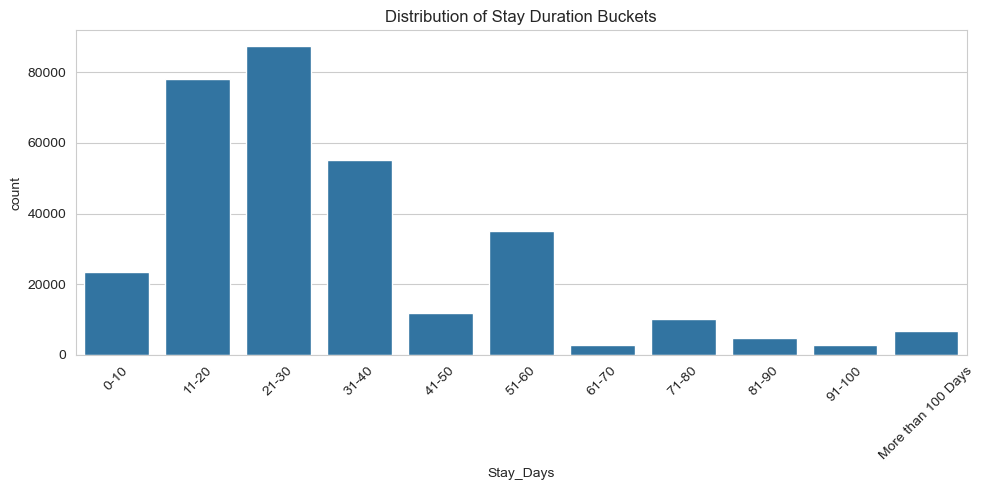

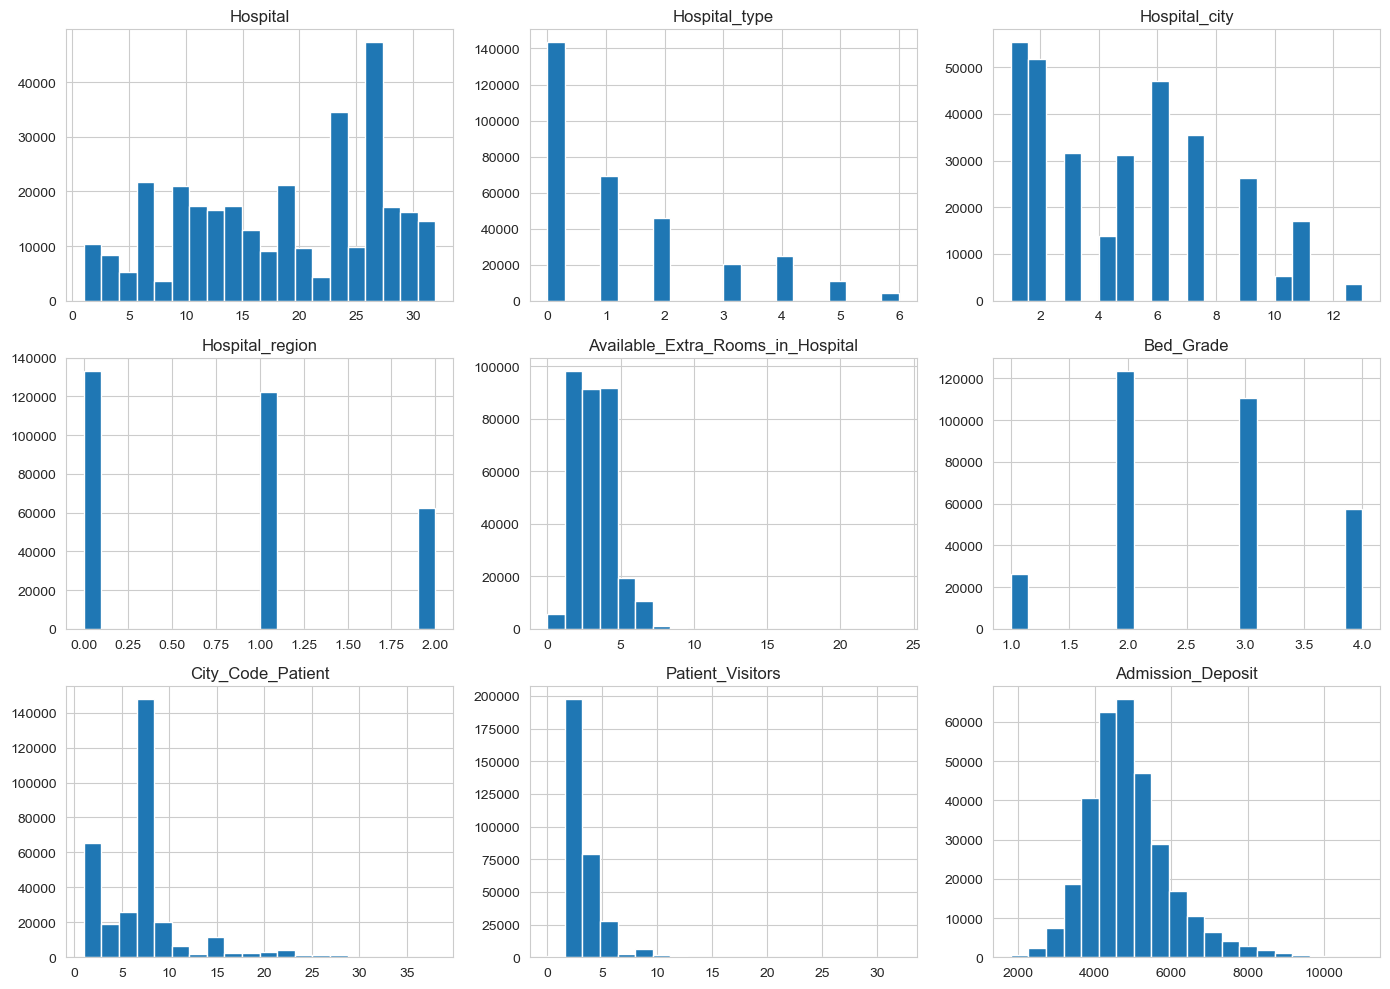

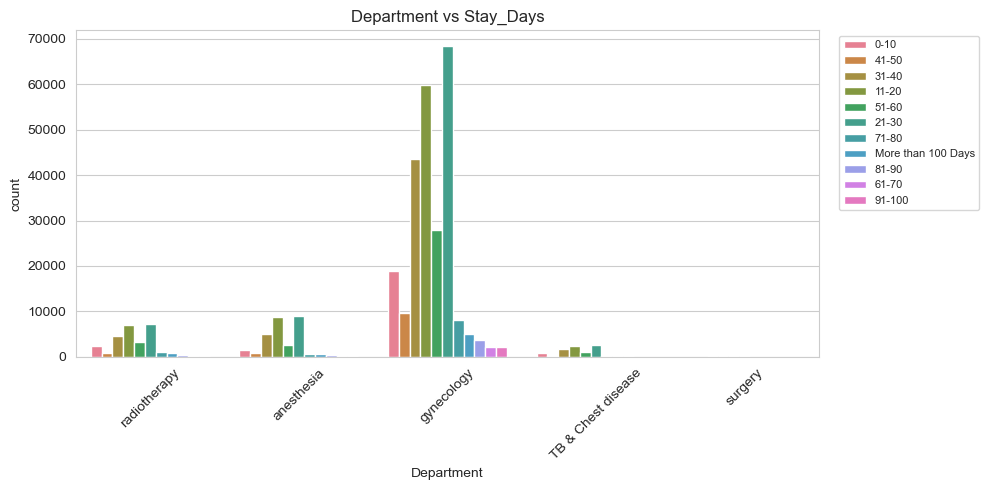

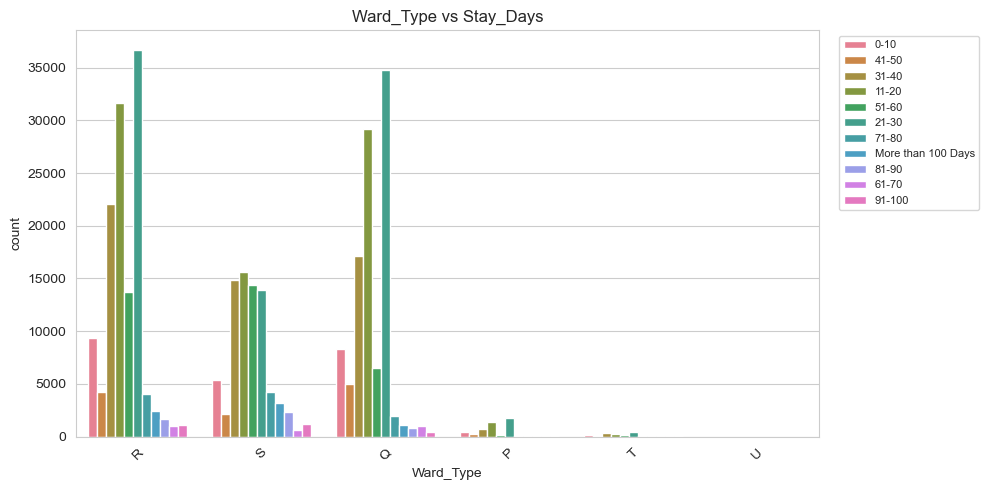

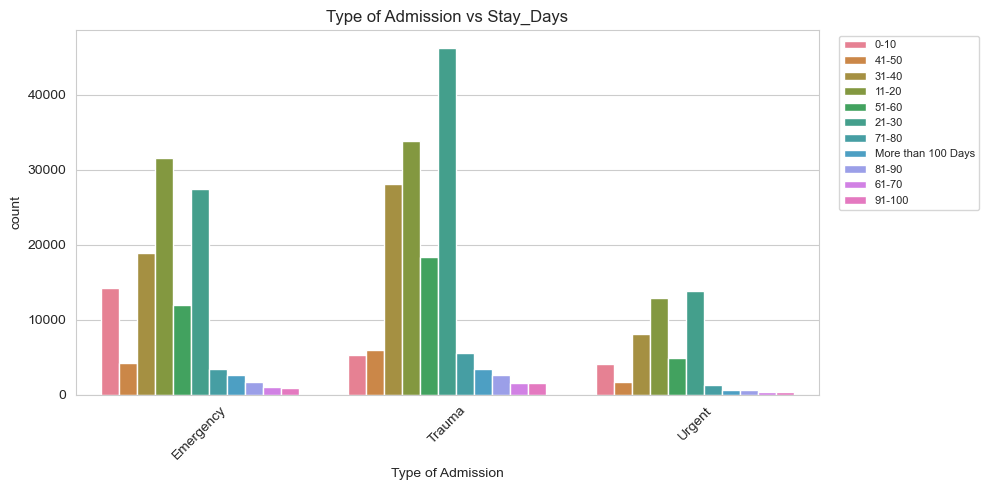

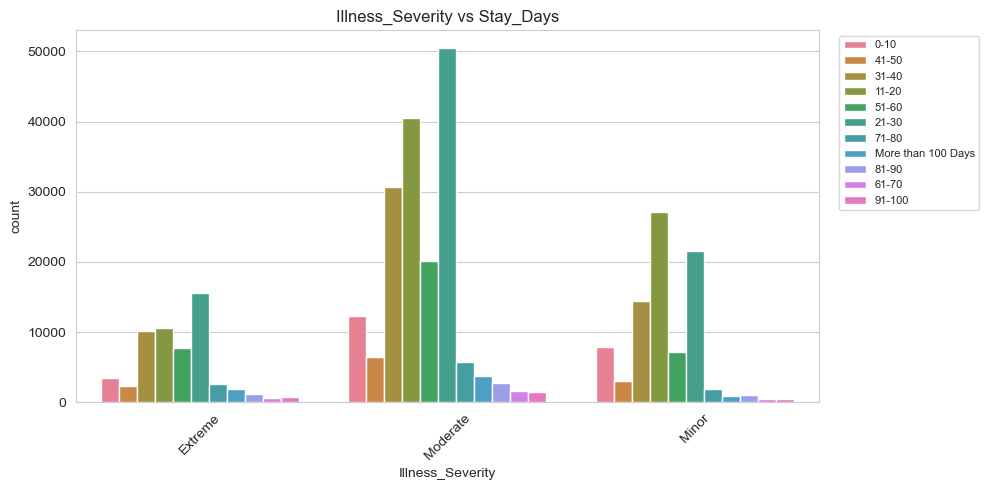

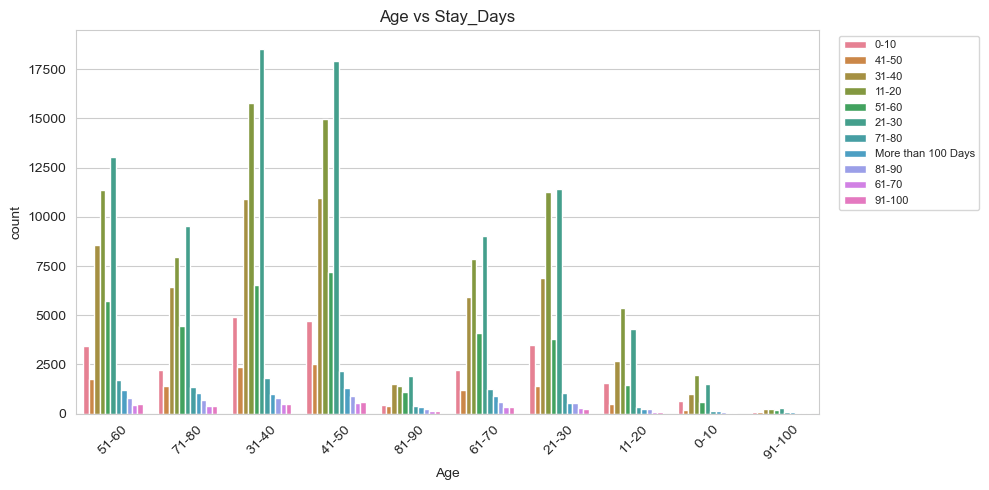

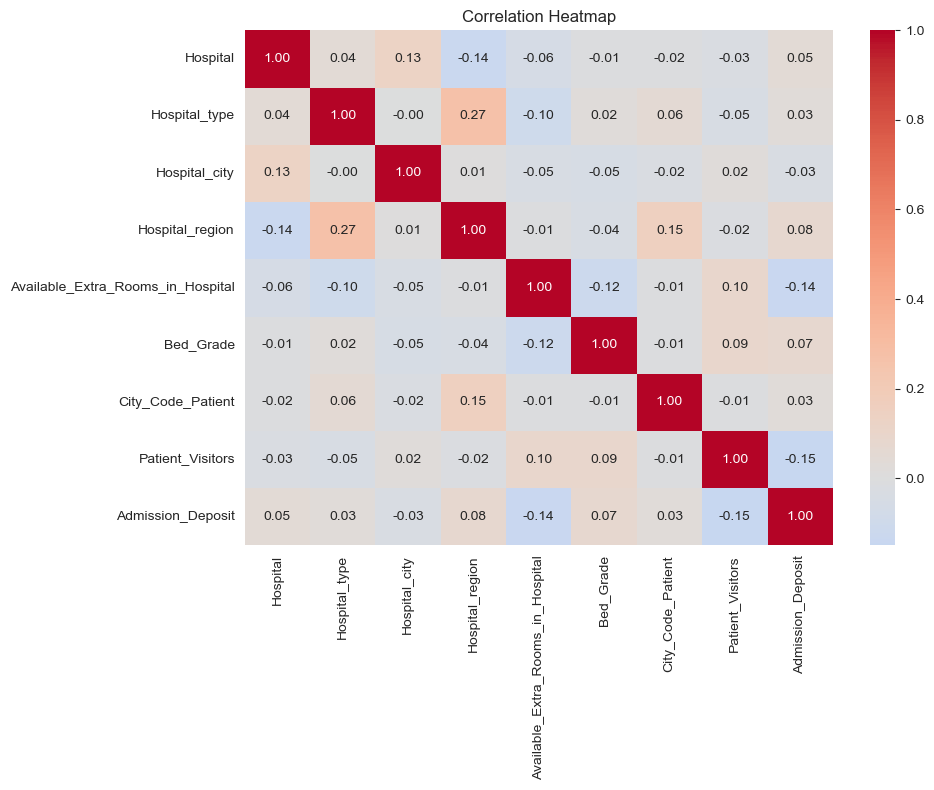

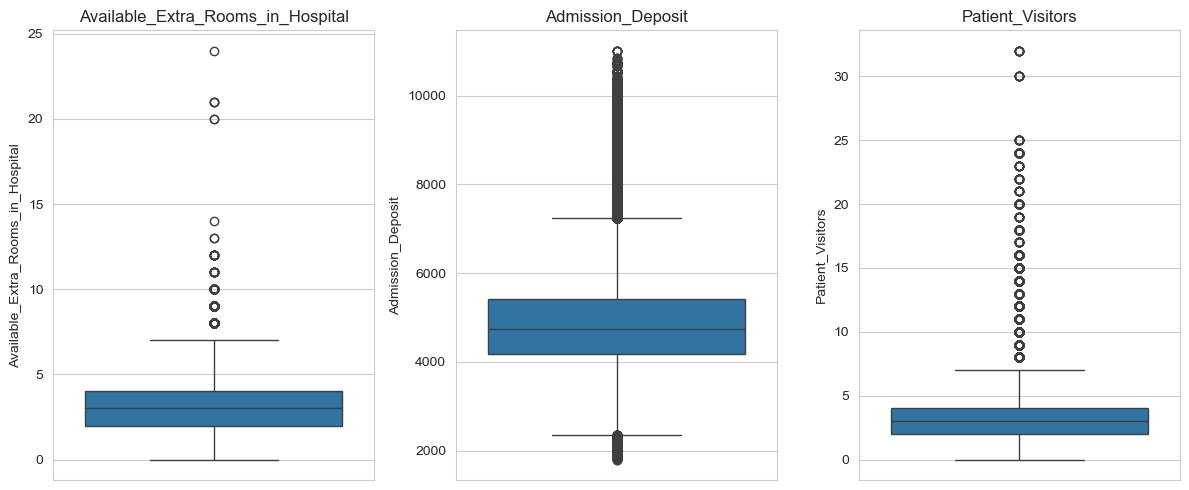


Patients with multiple visits: 71668
patientid
66714     50
91292     43
38525     39
101359    36
33491     34
32886     32
6645      31
99644     30
31203     30
126596    29
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# ---------- 1. Load data ----------
df = pd.read_csv(r'C:\Users\Admin\OneDrive\New folder\AI-Powered-Task-Management-System\host_train.csv (2).xls')

# ---------- 2. Basic structure ----------
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nFirst rows:\n", df.head())

# ---------- 3. Missing values ----------
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print("\nMissing values:\n", missing_df[missing_df['missing_count'] > 0])

# ---------- 4. Duplicates ----------
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate patient IDs (repeat patients):", df['patientid'].duplicated().sum())

# ---------- 5. Separate column types ----------
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("\nNumerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# ---------- 6. Summary stats ----------
print("\nNumeric summary:\n", df[num_cols].describe().T)
print("\nCategorical summary:\n", df[cat_cols].describe().T)

# ---------- 7. Unique values per categorical column ----------
for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts())

# ---------- 8. Target variable: Stay_Days ----------
print("\nStay_Days distribution:\n", df['Stay_Days'].value_counts().sort_index())

plt.figure(figsize=(10, 5))
order = sorted(df['Stay_Days'].dropna().unique())
sns.countplot(data=df, x='Stay_Days', order=order)
plt.xticks(rotation=45)
plt.title('Distribution of Stay Duration Buckets')
plt.tight_layout()
plt.show()

# ---------- 9. Numerical feature distributions ----------
num_features = [c for c in num_cols if c not in ['case_id', 'patientid']]
df[num_features].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# ---------- 10. Categorical vs target (Stay_Days) ----------
for col in ['Department', 'Ward_Type', 'Type of Admission', 'Illness_Severity', 'Age']:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, hue='Stay_Days')
    plt.title(f'{col} vs Stay_Days')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

# ---------- 11. Correlation heatmap (numeric only) ----------
plt.figure(figsize=(10, 8))
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# ---------- 12. Boxplots for outlier detection ----------
plt.figure(figsize=(12, 5))
for i, col in enumerate(['Available_Extra_Rooms_in_Hospital', 'Admission_Deposit', 'Patient_Visitors'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# ---------- 13. Repeat patient behavior ----------
patient_visit_counts = df['patientid'].value_counts()
print("\nPatients with multiple visits:", (patient_visit_counts > 1).sum())
print(patient_visit_counts.head(10))

 Conclusions:
 
    Data quality

The dataset is large (318,438 rows × 18 columns) and in solid shape overall: no duplicate records, and missing values confined to two columns (Bed_Grade, City_Code_Patient), both float-typed due to the presence of NaNs — low enough in volume to impute with mode/median without materially distorting the distributions.
Several columns arrive pre-encoded as integers (Hospital, Hospital_type, Hospital_city, Hospital_region, City_Code_Patient) rather than raw labels — useful for tree-based models as-is, but they should not be treated as continuous/linear features if a linear model is used later.
Type of Admission has a space in its name — recommend renaming to Admission_Type for consistency and easier programmatic access.

Key findings from EDA

The target Stay_Days is highly imbalanced across its 11 ordinal buckets — 21-30 and 11-20 dominate (~87K and ~78K records respectively), while mid-to-long buckets (61-70, 81-90, 91-100) each have under 5K records. Stratified splitting and class weighting (or bucket consolidation) will be needed in modelling.
Illness_Severity and Type of Admission clearly shift the shape of the stay-length distribution (not just its scale) — confirming both are genuinely predictive categorical features rather than volume proxies.
Department and Ward_Type are dominated by a small number of categories (Gynecology; Wards R/S/Q) — rare categories (surgery, TB & Chest disease; Wards P/T/U) should be grouped into "Other" to avoid sparse, noisy levels.
Age shows a moderate relationship with stay length, with the largest and most reliable signal in the 31-60 age range; very young and very old brackets are sparse and less statistically reliable.
Age and Stay_Days are both ordinal string ranges and must be explicitly ordinal-encoded (not one-hot or left as arbitrary strings) in the next modelling phase — this also fixes the mis-ordered legend seen in the current bar plots.
Available_Extra_Rooms_in_Hospital and Patient_Visitors are both right-skewed with long tails — candidates for outlier capping or log-transformation before modelling.
Admission_Deposit is the cleanest numeric feature, roughly bell-shaped and centered ~4,500-5,000 — usable with standard scaling as-is.

Deliverables

Cleaned dataset: data/processed/train_clean.csv (318,438 rows × 18 columns, missing values imputed)
This notebook with all EDA visualizations and observations.